import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Create Dataset

In [2]:
data = {
    "Engine": [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600],
    "Mileage": [28, 25, 23, 21, 19, 17, 16, 14, 13, 12]
}

df = pd.DataFrame(data)

print(df)

   Engine  Mileage
0     800       28
1    1000       25
2    1200       23
3    1400       21
4    1600       19
5    1800       17
6    2000       16
7    2200       14
8    2400       13
9    2600       12


Data Visualization

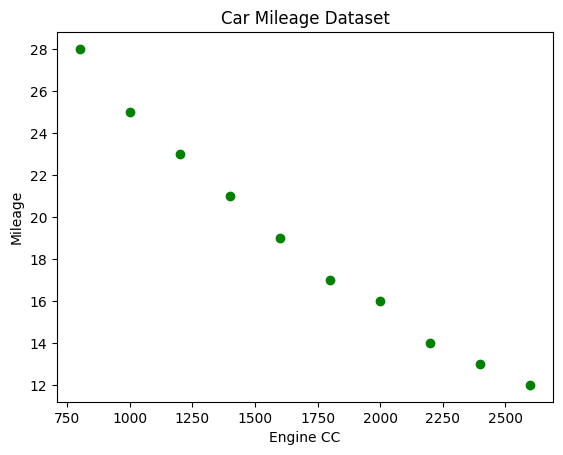

In [3]:
plt.scatter(df["Engine"], df["Mileage"], color="green")
plt.xlabel("Engine CC")
plt.ylabel("Mileage")
plt.title("Car Mileage Dataset")
plt.show()

Split Data

In [4]:
X = df[["Engine"]]
y = df["Mileage"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

Train Linear Regression Model

In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Prediction

In [6]:
prediction = model.predict(X_test)

print(prediction)

[12.53033268 23.23874755]


Compare Actual vs Predicted

In [7]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": prediction
})

print(result)

   Actual  Predicted
8      13  12.530333
2      23  23.238748


Accuracy

In [8]:
print("MAE :", mean_absolute_error(y_test, prediction))

print("MSE :", mean_squared_error(y_test, prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))

print("R2 Score :", r2_score(y_test, prediction))

MAE : 0.35420743639921604
MSE : 0.1387938924866238
RMSE : 0.3725505234013553
R2 Score : 0.994448244300535


Regression Line

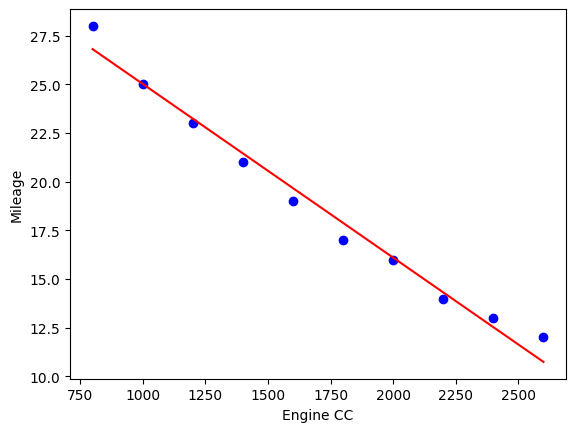

In [9]:
plt.scatter(X, y, color="blue")

plt.plot(X, model.predict(X), color="red")

plt.xlabel("Engine CC")
plt.ylabel("Mileage")

plt.show()

Predict New Car Mileage

In [10]:
new_car = pd.DataFrame({"Engine": [1700]})

mileage = model.predict(new_car)

print("Predicted Mileage =", mileage[0], "km/l")

Predicted Mileage = 18.776908023483365 km/l


Polynomial Regression

In [11]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()

poly_model.fit(X_poly, y)

new_data = pd.DataFrame({"Engine": [1700]})

poly_prediction = poly_model.predict(poly.transform(new_data))

print("Polynomial Prediction :", poly_prediction[0])

Polynomial Prediction : 18.050000000001646
